# Data formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from cycler import cycler

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2["FIPS"] = df_2["FIPS"].fillna(0)
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_2["FIPS"] = df_2["FIPS"].astype(int).astype(str).str.zfill(5)
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
df_1 = df_1[np.isfinite(df_1['filings_2020_p2'])]
df_2 = df_2[np.isfinite(df_2['filings_2020_p2'])]

In [ ]:
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()
disaster_list = dec["disasterNumber"].unique().astype(str)

# Census Tract level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
144
144
0
No control GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
242
413
171
--- GEOID 47157000100 completed ---
--- GEOID 47157000200 completed ---
--- GEOID 47157000300 completed ---
--- GEOID 47157000400 completed ---
--- GEOID 47157000600 completed ---
--- GEOID 47157000700 completed ---
--- GEOID 47157000800 completed ---
--- GEOID 47157000900 completed ---
--- GEOID 47157001100 completed ---
--- GEOID 47157001200 completed ---
--- GE

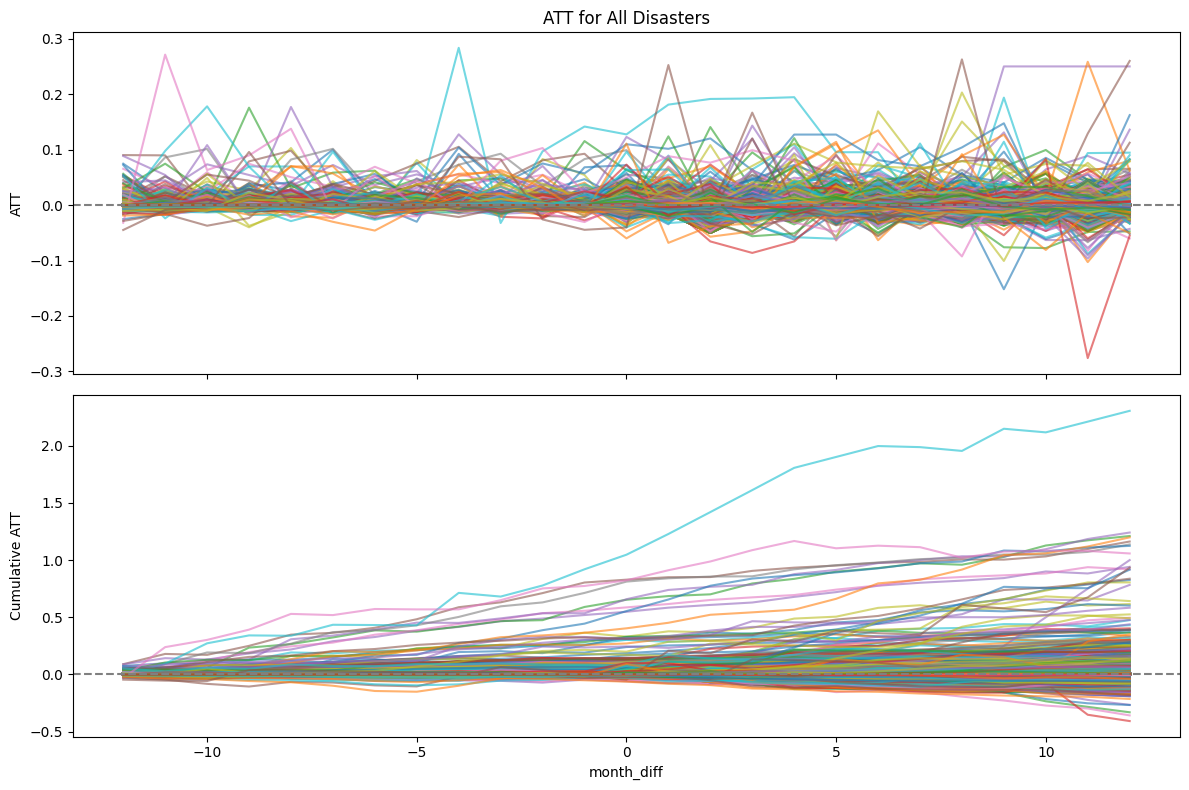

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_1['state'] = df_1['state'].astype(str)

# Dictionary
att_all = {}
cum_att_all = {}

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_1.loc[df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])

    # --- df_state & Control GEOIDs ---
    state_code = str(fips[0])[:2]
    df_state = df_1[df_1["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[df_trim["GEOID"].isin(valid_geoids) & df_trim["GEOID"].isin(control_geoids)].copy()

        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all to DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all to DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- Save ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all.csv", index=False)

print("Saved att_all.csv and cum_att_all.csv with GEOID and disaster_id columns.")

Saved att_all.csv and cum_att_all.csv with GEOID and disaster_id columns.


/tmp/ipython-input-82047874.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


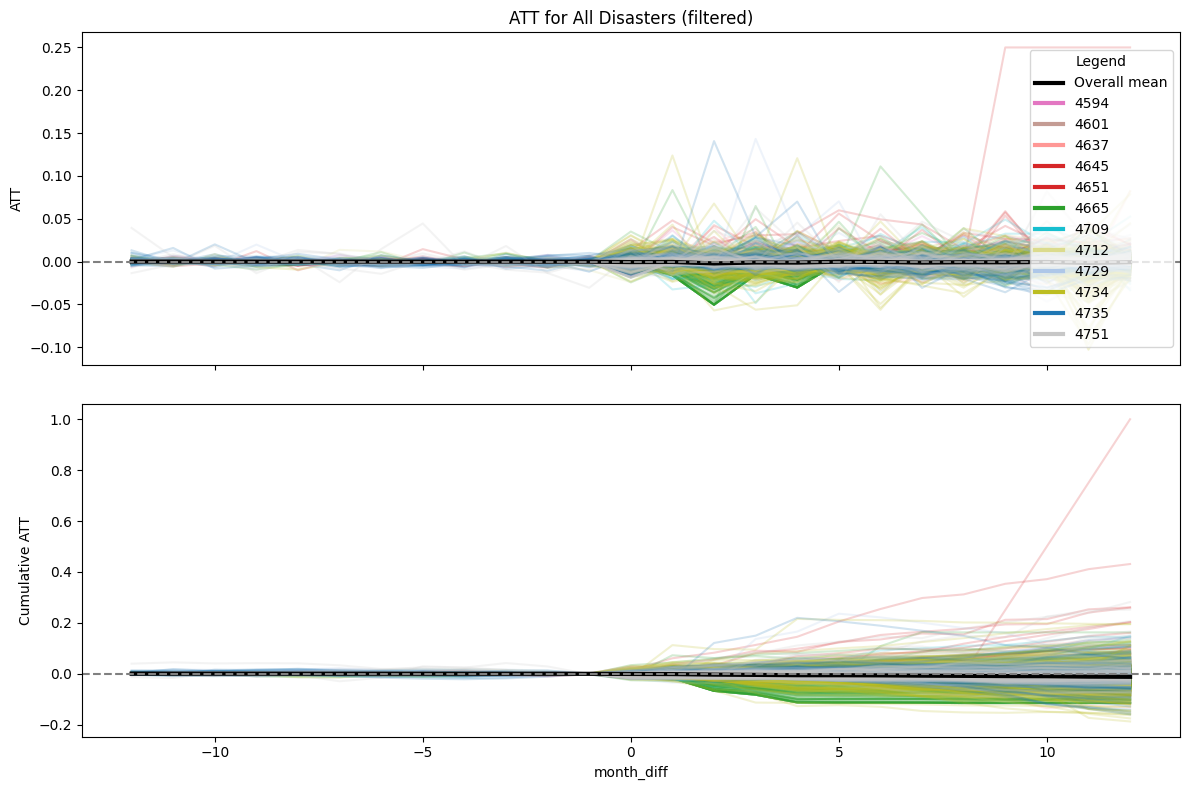

Filtered GEOIDs: ['47157000100', '47157000200', '47157000800', '47157001400', '47157001600', '47157001700', '47157001900', '47157002100', '47157002500', '47157002600', '47157002900', '47157003100', '47157003200', '47157003300', '47157003400', '47157003500', '47157003600', '47157003700', '47157003900', '47157004200', '47157004300', '47157004600', '47157006300', '47157006500', '47157006600', '47157007200', '47157007400', '47157007821', '47157008500', '47157008700', '47157008800', '47157009100', '47157009202', '47157009300', '47157009400', '47157009501', '47157009502', '47157009600', '47157010220', '47157010300', '47157010500', '47157010710', '47157011100', '47157011300', '47157011401', '47157020102', '47157020210', '47157020221', '47157020301', '47157020400', '47157020524', '47157020531', '47157020632', '47157020633', '47157020635', '47157020651', '47157020654', '47157020656', '47157020657', '47157020658', '47157020834', '47157020837', '47157020901', '47157020902', '47157021022', '471570

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all.csv",
    index=False
)

print("Saved filtered_att_all.csv and filtered_cum_att_all.csv")


Saved filtered_att_all.csv and filtered_cum_att_all.csv


##Placebo test

In [ ]:
disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n_placebo = 100
target_disasters = set(disaster_type_dict.keys())

summary_rows = {}

# =====================================================
# Placebo loop
# =====================================================
for disaster_id in disaster_list:

    if str(disaster_id) not in target_disasters:
        continue

    # -----------------------------
    # Disaster timing & state
    # -----------------------------
    impact_month = int(
        dec.loc[
            dec["disasterNumber"].astype(str) == disaster_id,
            "month_num"
        ].iloc[0]
    )

    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id,
        "FIPS"
    ].unique()

    treat_geoids = df_1.loc[
        df_1["GEOID"].astype(str).str[:5].isin(fips),
        "GEOID"
    ].unique()

    state_code = str(fips[0])[:2]
    df_state = df_1[df_1["state"].astype(str) == state_code].copy()

    # -----------------------------
    # Time window
    # -----------------------------
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # -----------------------------
    # Balanced panel
    # -----------------------------
    all_months = set(range(-12, 13))
    control_geoids = df_state.loc[
        ~df_state["GEOID"].isin(treat_geoids), "GEOID"
    ].unique()

    valid_geoids = [
        g for g in control_geoids
        if all_months.issubset(
            set(df_trim.loc[df_trim["GEOID"] == g, "month_diff"])
        )
    ]

    if len(valid_geoids) < n_placebo + 1:
        continue

    # -----------------------------
    # Placebo draw
    # -----------------------------
    placebo_geos = np.random.choice(
        valid_geoids, size=n_placebo, replace=False
    )

    placebo_tminus1 = []
    placebo_paths = []

    # -----------------------------
    # Placebo SC loop
    # -----------------------------
    for pgeo in placebo_geos:

        df_tr = df_trim[df_trim["GEOID"] == pgeo]
        df_co = df_trim[
            (df_trim["GEOID"].isin(valid_geoids)) &
            (df_trim["GEOID"] != pgeo)
        ]

        df_sc = pd.concat([df_tr, df_co])

        try:
            y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
                df_sc,
                geo_col="GEOID",
                time_col="month_diff",
                y_col="filings_2020_p2",
                tr_geos=[pgeo],
                tr_start=0
            )

            model = SyntheticControl()
            model.fit(
                y_pre_co.values,
                y_pre_tr.mean(axis=1).values
            )

            y_co = pd.concat([y_pre_co, y_post_co])
            y_tr = pd.concat([y_pre_tr, y_post_tr])
            y_hat = model.predict(y_co.values)

            att = y_tr.mean(axis=1) - y_hat
            cum_att = att.cumsum()

            if (-1 in cum_att.index) and all(t in cum_att.index for t in range(0, 13)):
                placebo_tminus1.append(cum_att.loc[-1])
                placebo_paths.append(cum_att.loc[0:12])

        except Exception:
            continue

    # =====================================================
    # IQR filtering at t=-1
    # =====================================================
    placebo_tminus1 = np.array(placebo_tminus1)

    if len(placebo_paths) == 0:
        continue

    q1 = np.quantile(placebo_tminus1, 0.25)
    q3 = np.quantile(placebo_tminus1, 0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    valid_idx = np.where(
        (placebo_tminus1 >= lower_bound) &
        (placebo_tminus1 <= upper_bound)
    )[0]

    if len(valid_idx) == 0:
        continue

    # Filtered placebo_mat
    placebo_mat = pd.concat(placebo_paths, axis=1).T
    placebo_mat = placebo_mat.iloc[valid_idx]

    # -----------------------------
    # Summary (t = 0〜12)
    # -----------------------------
    row = {
        "disaster_id": disaster_id,
        "n_placebo": placebo_mat.shape[0]
    }

    for t in range(0, 13):
        row[f"mean_t{t}"] = placebo_mat[t].mean()
        row[f"se_t{t}"] = placebo_mat[t].std(ddof=1) / np.sqrt(placebo_mat.shape[0])
        row[f"q05_t{t}"] = np.quantile(placebo_mat[t], 0.05)
        row[f"q95_t{t}"] = np.quantile(placebo_mat[t], 0.95)

    summary_rows[disaster_id] = row


# =====================================================
# Summary table
# =====================================================
placebo_summary_df = pd.DataFrame.from_dict(
    summary_rows, orient="index"
).reset_index(drop=True)


In [ ]:
placebo_summary_df

,disaster_id,n_placebo,mean_t0,se_t0,q05_t0,q95_t0,mean_t1,se_t1,q05_t1,q95_t1,...,q05_t10,q95_t10,mean_t11,se_t11,q05_t11,q95_t11,mean_t12,se_t12,q05_t12,q95_t12
0,4735,88,-0.002525,0.000491,-0.009569,0.005277,-0.002105,0.000733,-0.011844,0.009774,...,-0.044802,0.038412,-0.008573,0.002857,-0.049881,0.038974,-0.008738,0.003135,-0.054878,0.048457
1,4729,87,-0.001866,0.000579,-0.009639,0.005569,-0.002333,0.000866,-0.012822,0.011171,...,-0.052075,0.041812,-0.008924,0.003212,-0.055885,0.041301,-0.009074,0.003518,-0.057090,0.040843
2,4665,82,-0.002487,0.000696,-0.011241,0.004308,-0.001625,0.002478,-0.016494,0.008174,...,-0.100494,0.058603,0.001650,0.012990,-0.094728,0.056794,0.001867,0.013024,-0.098574,0.056636
3,4651,100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4645,88,-0.000942,0.000666,-0.010205,0.009753,0.000344,0.001190,-0.012715,0.016758,...,-0.044931,0.081761,0.003227,0.004676,-0.048700,0.087702,0.002781,0.004943,-0.052258,0.091841
5,4637,87,-0.002620,0.000833,-0.016002,0.012014,-0.003672,0.001172,-0.022782,0.014418,...,-0.104000,0.083523,-0.012653,0.007108,-0.106719,0.093930,-0.012284,0.007544,-0.108191,0.097667
6,4601,83,-0.001993,0.000733,-0.012815,0.007598,-0.002775,0.000920,-0.016492,0.009568,...,-0.054968,0.047055,-0.004216,0.004285,-0.059320,0.077709,-0.005706,0.004735,-0.061738,0.076854
7,4594,78,-0.001671,0.000688,-0.009341,0.005374,-0.001668,0.000747,-0.009725,0.005983,...,-0.019080,0.056768,0.005518,0.002854,-0.019792,0.062666,0.007014,0.003567,-0.022103,0.067214
8,4751,86,-0.003550,0.000949,-0.015667,0.006977,-0.003565,0.001265,-0.022572,0.011548,...,-0.071802,0.049831,-0.002995,0.005754,-0.071595,0.047251,-0.002714,0.006118,-0.074250,0.042714
9,4734,88,-0.000666,0.000667,-0.006849,0.009513,-0.000873,0.000827,-0.008893,0.013003,...,-0.056199,0.022742,-0.019069,0.003265,-0.065930,0.025136,-0.020377,0.003524,-0.069439,0.025832


In [ ]:
# --- Save --- ->
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
placebo_summary_df.to_csv(save_dir + "placebo_summary_df.csv", index=False)

# Zip level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
0
No treatment GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
0
No treatment GEOIDs available for disaster 4735, skipping...

=== Processing Disaster 4732 ===
0
No treatment GEOIDs available for disaster 4732, skipping...

=== Processing Disaster 4730 ===
0
No treatment GEOIDs available for disaster 4730, skipping...

=== Processing Disaster 4729 ===
0
No treatment GEOIDs available for disaster 4729, skipping...

=== Processing Disaster 4726 

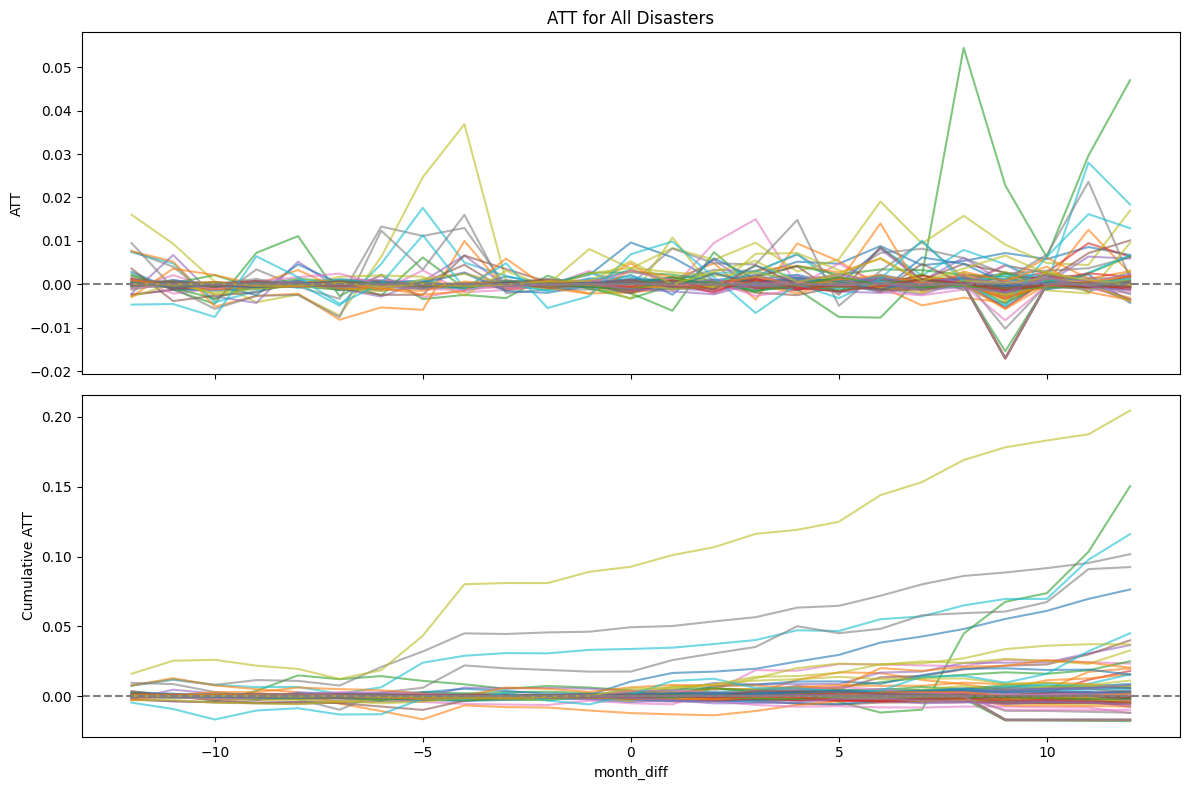

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_2['state'] = df_2['state'].astype(str)
df_state["GEOID"] = df_state["GEOID"].astype(str)
df_trim["GEOID"] = df_trim["GEOID"].astype(str)
treat_geoids = treat_geoids.astype(str)
control_geoids = control_geoids.astype(str)


# Dictionary
att_all = {}
cum_att_all = {}

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_2.loc[df_2["FIPS"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])
    print(impact_month)

    # --- df_state & Control GEOIDs ---
    state_code = str(fips[0])[:2]
    df_state = df_2[df_2["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        # --- Tre + Control ---
        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[df_trim["GEOID"].isin(valid_geoids) & df_trim["GEOID"].isin(control_geoids)].copy()
        df_sc = pd.concat([df_tr, df_co])

        # --- Rashape ---
        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        # --- Skip NaN ---
        if y_pre_co.isna().any().any() or y_pre_tr.isna().any().any():
            print(f"Treatment GEOID {geo} or controls have NaN, skip")
            continue

        # --- Synthetic Control ---
        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")


# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all to DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all to DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- Save ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_zip.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_zip.csv", index=False)

print("Saved att_all_zip.csv and cum_att_all_zip.csv with GEOID and disaster_id columns.")

Saved att_all_zip.csv and cum_att_all_zip.csv with GEOID and disaster_id columns.


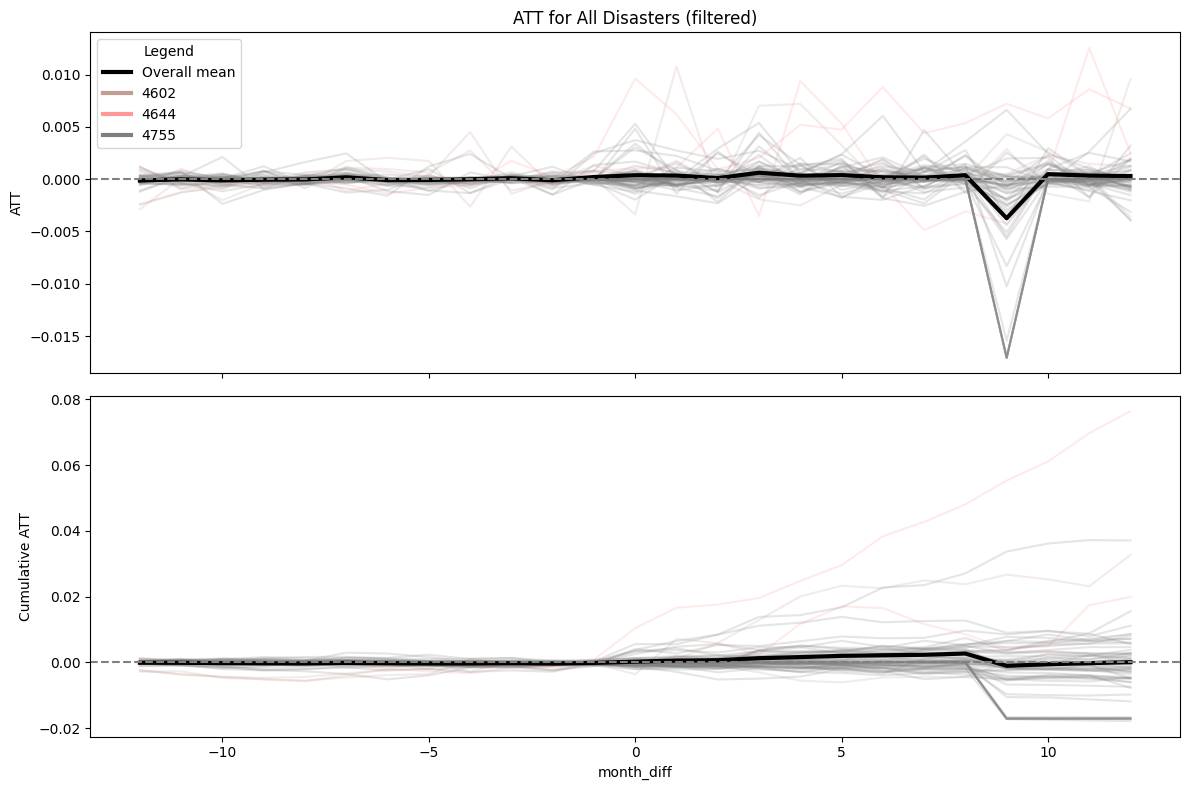

Filtered GEOIDs: ['23113', '23114', '23803', '23838', '23112', '23113', '10466', '10471', '10475', '10550', '10704', '10705', '10803', '11001', '11003', '11004', '11005', '11020', '11040', '11201', '11203', '11204', '11205', '11206', '11207', '11208', '11209', '11211', '11212', '11213', '11214', '11215', '11216', '11217', '11218', '11220', '11221', '11222', '11223', '11224', '11225', '11228', '11229', '11230', '11231', '11232', '11233', '11234', '11235', '11236', '11237', '11238', '11249', '11414', '11416', '11417', '11421', '11422', '11559', '11580', '11691']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_zip.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_zip.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_zip.csv",
    index=False
)

print("Saved filtered_att_all_zip.csv and filtered_cum_att_all_zip.csv")


Saved filtered_att_all_zip.csv and filtered_cum_att_all_zip.csv


## Placebo test

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n_placebo = 100
target_disasters = set(disaster_type_dict.keys())

summary_rows = {}

# =====================================================
# Placebo loop
# =====================================================
for disaster_id in disaster_list:

    if str(disaster_id) not in target_disasters:
        continue

    # -----------------------------
    # Disaster timing & state
    # -----------------------------
    impact_month = int(
        dec.loc[
            dec["disasterNumber"].astype(str) == disaster_id,
            "month_num"
        ].iloc[0]
    )

    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id,
        "FIPS"
    ].unique()

    treat_geoids = df_2.loc[
        df_2["GEOID"].astype(str).str[:5].isin(fips),
        "GEOID"
    ].unique()

    state_code = str(fips[0])[:2]
    df_state = df_2[df_2["state"].astype(str) == state_code].copy()

    # -----------------------------
    # Time window
    # -----------------------------
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # -----------------------------
    # Balanced panel
    # -----------------------------
    all_months = set(range(-12, 13))
    control_geoids = df_state.loc[
        ~df_state["GEOID"].isin(treat_geoids), "GEOID"
    ].unique()

    valid_geoids = [
        g for g in control_geoids
        if all_months.issubset(
            set(df_trim.loc[df_trim["GEOID"] == g, "month_diff"])
        )
    ]

    if len(valid_geoids) < n_placebo + 1:
        continue

    # -----------------------------
    # Placebo draw
    # -----------------------------
    placebo_geos = np.random.choice(
        valid_geoids, size=n_placebo, replace=False
    )

    placebo_tminus1 = []
    placebo_paths = []

    # -----------------------------
    # Placebo SC loop
    # -----------------------------
    for pgeo in placebo_geos:

        df_tr = df_trim[df_trim["GEOID"] == pgeo]
        df_co = df_trim[
            (df_trim["GEOID"].isin(valid_geoids)) &
            (df_trim["GEOID"] != pgeo)
        ]

        df_sc = pd.concat([df_tr, df_co])

        try:
            y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
                df_sc,
                geo_col="GEOID",
                time_col="month_diff",
                y_col="filings_2020_p2",
                tr_geos=[pgeo],
                tr_start=0
            )

            model = SyntheticControl()
            model.fit(
                y_pre_co.values,
                y_pre_tr.mean(axis=1).values
            )

            y_co = pd.concat([y_pre_co, y_post_co])
            y_tr = pd.concat([y_pre_tr, y_post_tr])
            y_hat = model.predict(y_co.values)

            att = y_tr.mean(axis=1) - y_hat
            cum_att = att.cumsum()

            if (-1 in cum_att.index) and all(t in cum_att.index for t in range(0, 13)):
                placebo_tminus1.append(cum_att.loc[-1])
                placebo_paths.append(cum_att.loc[0:12])

        except Exception:
            continue

    placebo_tminus1 = np.array(placebo_tminus1)

    if len(placebo_paths) == 0:
        continue

    # =====================================================
    # IQR filtering at t = -1
    # =====================================================
    q1 = np.quantile(placebo_tminus1, 0.25)
    q3 = np.quantile(placebo_tminus1, 0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    valid_idx = np.where(
        (placebo_tminus1 >= lower_bound) &
        (placebo_tminus1 <= upper_bound)
    )[0]

    if len(valid_idx) == 0:
        continue

    placebo_mat = pd.concat(placebo_paths, axis=1).T
    placebo_mat = placebo_mat.iloc[valid_idx]

    # -----------------------------
    # Summary (t = 0〜12)
    # -----------------------------
    row = {
        "disaster_id": disaster_id,
        "n_placebo": placebo_mat.shape[0]
    }

    for t in range(0, 13):
        row[f"mean_t{t}"] = placebo_mat[t].mean()
        row[f"se_t{t}"] = placebo_mat[t].std(ddof=1) / np.sqrt(placebo_mat.shape[0])
        row[f"q05_t{t}"] = np.quantile(placebo_mat[t], 0.05)
        row[f"q95_t{t}"] = np.quantile(placebo_mat[t], 0.95)

    summary_rows[disaster_id] = row

# =====================================================
# Summary table
# =====================================================
placebo_summary_df2 = pd.DataFrame.from_dict(
    summary_rows, orient="index"
).reset_index(drop=True)


In [ ]:
placebo_summary_df2.head()

,disaster_id,n_placebo,mean_t0,se_t0,q05_t0,q95_t0,mean_t1,se_t1,q05_t1,q95_t1,...,q05_t10,q95_t10,mean_t11,se_t11,q05_t11,q95_t11,mean_t12,se_t12,q05_t12,q95_t12
0,4755,81,-0.000324,0.000155,-0.001879,0.002464,-0.000333,0.000229,-0.002463,0.002698,...,-0.007541,0.007977,-0.000268,0.000696,-0.007177,0.010451,-0.000568,0.000717,-0.008062,0.008155


# Pooled placebo

In [ ]:
# -----------------------------------------------------
# Pooled
# -----------------------------------------------------
df_pool = pd.concat([df_1, df_2], axis=0).copy()

df_pool["GEOID"] = df_pool["GEOID"].astype(str)

IQR-filtered placebo units: 86


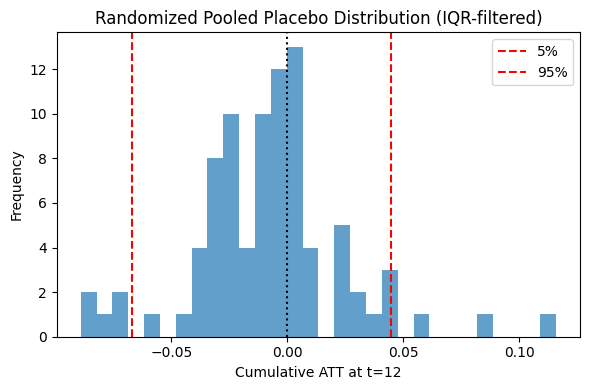

{'n_placebo': 86,
 'mean_t0': np.float64(-0.0014774276092973586),
 'se_t0': np.float64(0.0005951510450491637),
 'q05_t0': np.float64(-0.010789303193409622),
 'q95_t0': np.float64(0.007259348443770798),
 'mean_t1': np.float64(-0.0014893892696382625),
 'se_t1': np.float64(0.0008514329526038747),
 'q05_t1': np.float64(-0.012876001240555626),
 'q95_t1': np.float64(0.013011276033378788),
 'mean_t2': np.float64(-0.0018904848038902213),
 'se_t2': np.float64(0.0012058311070041944),
 'q05_t2': np.float64(-0.019624840702100722),
 'q95_t2': np.float64(0.016159767284992008),
 'mean_t3': np.float64(-0.0029727208715411724),
 'se_t3': np.float64(0.0014169019879153016),
 'q05_t3': np.float64(-0.02415149305522992),
 'q95_t3': np.float64(0.01846707802838861),
 'mean_t4': np.float64(-0.0024529067430267347),
 'se_t4': np.float64(0.0014575511571693937),
 'q05_t4': np.float64(-0.023736994979638014),
 'q95_t4': np.float64(0.021522043152415078),
 'mean_t5': np.float64(-0.003030476449803051),
 'se_t5': np.floa

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_target = 100
target_disasters = set(disaster_type_dict.keys())
filtered_disaster_list = [
    d for d in disaster_list if str(d) in target_disasters
]

all_placebo_paths = []
all_tminus1 = []


# =====================================================
# SC
# =====================================================
while len(all_placebo_paths) < n_target:

    iter_count += 1

    disaster_id = np.random.choice(filtered_disaster_list)

    try:
        impact_month = int(
            dec.loc[
                dec["disasterNumber"].astype(str) == disaster_id,
                "month_num"
            ].iloc[0]
        )
    except:
        continue

    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id,
        "FIPS"
    ].unique()

    state_code = str(fips[0])[:2]

    df_state = df_pool[
        df_pool["state"].astype(str) == state_code
    ].copy()

    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    geoids_str = df_pool["GEOID"].astype(str)
    fips_str = df_pool["FIPS"].astype(str)

    if geoids_str.str.len().max() <= 5:
        treat_geoids = df_pool.loc[
            geoids_str.isin(fips),
            "GEOID"
        ].unique()
    else:
        treat_geoids = df_pool.loc[
            fips_str.str[:5].isin(fips),
            "GEOID"
        ].unique()

    all_months = set(range(-12, 13))

    control_geoids = df_state.loc[
        ~df_state["GEOID"].isin(treat_geoids),
        "GEOID"
    ].unique()

    valid_geoids = [
        g for g in control_geoids
        if all_months.issubset(
            set(df_trim.loc[df_trim["GEOID"] == g, "month_diff"])
        )
    ]

    if len(valid_geoids) == 0:
        continue

    pgeo = np.random.choice(valid_geoids)

    df_tr = df_trim[df_trim["GEOID"] == pgeo]
    df_co = df_trim[
        (df_trim["GEOID"].isin(valid_geoids)) &
        (df_trim["GEOID"] != pgeo)
    ]

    df_sc = pd.concat([df_tr, df_co])

    try:
        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc,
            geo_col="GEOID",
            time_col="month_diff",
            y_col="filings_2020_p2",
            tr_geos=[pgeo],
            tr_start=0
        )

        model = SyntheticControl()
        model.fit(
            y_pre_co.values,
            y_pre_tr.mean(axis=1).values
        )

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        att = y_tr.mean(axis=1) - y_hat
        cum_att = att.cumsum()

        if (-1 in cum_att.index) and \
           all(t in cum_att.index for t in range(0, 13)):

            all_placebo_paths.append(cum_att.loc[0:12])
            all_tminus1.append(cum_att.loc[-1])

    except Exception:
        continue

# =====================================================
# IQR filtering at t = -1
# =====================================================
all_tminus1 = np.array(all_tminus1)

if len(all_tminus1) == 0:
    raise ValueError("No valid placebo draws.")

q1 = np.quantile(all_tminus1, 0.25)
q3 = np.quantile(all_tminus1, 0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

valid_idx = np.where(
    (all_tminus1 >= lower_bound) &
    (all_tminus1 <= upper_bound)
)[0]

placebo_mat = pd.concat(all_placebo_paths, axis=1).T
placebo_mat = placebo_mat.iloc[valid_idx[:n_target]]

# -----------------------------
# n_placebo
# -----------------------------
n_placebo = placebo_mat.shape[0]
print(f"IQR-filtered placebo units: {n_placebo}")

# =====================================================
# Summary
# =====================================================
summary = {"n_placebo": n_placebo}

for t in range(0, 13):
    summary[f"mean_t{t}"] = placebo_mat[t].mean()
    summary[f"se_t{t}"] = placebo_mat[t].std(ddof=1) / np.sqrt(n_placebo)
    summary[f"q05_t{t}"] = np.quantile(placebo_mat[t], 0.05)
    summary[f"q95_t{t}"] = np.quantile(placebo_mat[t], 0.95)


# =====================================================
# Histogram
# =====================================================
plt.figure(figsize=(6, 4))
plt.hist(placebo_mat[12], bins=30, alpha=0.7)
plt.axvline(0, color="black", linestyle=":")
plt.axvline(summary["q05_t12"], color="red", linestyle="--", label="5%")
plt.axvline(summary["q95_t12"], color="red", linestyle="--", label="95%")
plt.legend()
plt.title("Randomized Pooled Placebo Distribution (IQR-filtered)")
plt.xlabel("Cumulative ATT at t=12")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

summary


In [ ]:
summary_df = pd.DataFrame([summary])
summary_df.to_csv("placebo_summary.csv", index=False)

In [ ]:
# --- Save --- -> goes to Fig 2
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
placebo_summary_df_all = pd.concat(
    [placebo_summary_df, placebo_summary_df2, summary_df],
    axis=0,
    ignore_index=True
)
placebo_summary_df_all.to_csv(save_dir + "placebo_summary_df_all.csv", index=False)

In [ ]:
placebo_summary_df_all

,disaster_id,n_placebo,mean_t0,se_t0,q05_t0,q95_t0,mean_t1,se_t1,q05_t1,q95_t1,...,q05_t10,q95_t10,mean_t11,se_t11,q05_t11,q95_t11,mean_t12,se_t12,q05_t12,q95_t12
0,4735,88,-0.002525,0.000491,-0.009569,0.005277,-0.002105,0.000733,-0.011844,0.009774,...,-0.044802,0.038412,-0.008573,0.002857,-0.049881,0.038974,-0.008738,0.003135,-0.054878,0.048457
1,4729,87,-0.001866,0.000579,-0.009639,0.005569,-0.002333,0.000866,-0.012822,0.011171,...,-0.052075,0.041812,-0.008924,0.003212,-0.055885,0.041301,-0.009074,0.003518,-0.057090,0.040843
2,4665,82,-0.002487,0.000696,-0.011241,0.004308,-0.001625,0.002478,-0.016494,0.008174,...,-0.100494,0.058603,0.001650,0.012990,-0.094728,0.056794,0.001867,0.013024,-0.098574,0.056636
3,4651,100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4645,88,-0.000942,0.000666,-0.010205,0.009753,0.000344,0.001190,-0.012715,0.016758,...,-0.044931,0.081761,0.003227,0.004676,-0.048700,0.087702,0.002781,0.004943,-0.052258,0.091841
5,4637,87,-0.002620,0.000833,-0.016002,0.012014,-0.003672,0.001172,-0.022782,0.014418,...,-0.104000,0.083523,-0.012653,0.007108,-0.106719,0.093930,-0.012284,0.007544,-0.108191,0.097667
6,4601,83,-0.001993,0.000733,-0.012815,0.007598,-0.002775,0.000920,-0.016492,0.009568,...,-0.054968,0.047055,-0.004216,0.004285,-0.059320,0.077709,-0.005706,0.004735,-0.061738,0.076854
7,4594,78,-0.001671,0.000688,-0.009341,0.005374,-0.001668,0.000747,-0.009725,0.005983,...,-0.019080,0.056768,0.005518,0.002854,-0.019792,0.062666,0.007014,0.003567,-0.022103,0.067214
8,4751,86,-0.003550,0.000949,-0.015667,0.006977,-0.003565,0.001265,-0.022572,0.011548,...,-0.071802,0.049831,-0.002995,0.005754,-0.071595,0.047251,-0.002714,0.006118,-0.074250,0.042714
9,4734,88,-0.000666,0.000667,-0.006849,0.009513,-0.000873,0.000827,-0.008893,0.013003,...,-0.056199,0.022742,-0.019069,0.003265,-0.065930,0.025136,-0.020377,0.003524,-0.069439,0.025832


# Descriptive statistics

In [ ]:
# ===============================
# 0. Prep
# ===============================
disaster_list = dec["disasterNumber"].astype(str).unique()
df_1["state"] = df_1["state"].astype(str)

balanced_data = []

# ===============================
# 1. Sample construction only
# ===============================
for disaster_id in disaster_list:
    print(f"\n=== Disaster {disaster_id} ===")

    # --- Treatment FIPS ---
    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id, "FIPS"
    ].unique()

    treat_geoids = df_1.loc[
        df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"
    ].unique()

    if len(treat_geoids) == 0:
        print("No treatment GEOIDs, skip")
        continue

    impact_month = int(
        dec.loc[
            dec["disasterNumber"].astype(str) == disaster_id, "month_num"
        ].iloc[0]
    )

    # --- Restrict to state ---
    state_code = str(fips[0])[:2]
    df_state = df_1[df_1["state"] == state_code].copy()

    # --- month diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Balanced GEOIDs ---
    all_months = set(range(-12, 13))
    valid_geoids = [
        geo for geo in df_trim["GEOID"].unique()
        if all_months.issubset(
            set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"])
        )
    ]

    if len(valid_geoids) == 0:
        print("No balanced GEOIDs, skip")
        continue

    df_balanced = df_trim[df_trim["GEOID"].isin(valid_geoids)].copy()
    df_balanced["disaster"] = disaster_id

    # Treated dummy
    df_balanced["treated"] = df_balanced["GEOID"].isin(treat_geoids).astype(int)

    balanced_data.append(df_balanced)

# ===============================
# 2. Descriptive statistics
# ===============================
df_balanced_all = pd.concat(balanced_data, ignore_index=True)

desc_vars = ["filings_2020_p2"]

# --- disaster × treated ---
desc_by_disaster = (
    df_balanced_all
    .groupby(["disaster", "treated"])[desc_vars]
    .agg(["count", "mean", "std", "min", "max"])
)

valid_disasters = (
    desc_by_disaster
    .reset_index()
    .groupby("disaster")["treated"]
    .nunique()
)

valid_disasters = valid_disasters[valid_disasters == 2].index

desc_by_disaster = desc_by_disaster.loc[valid_disasters]

# --- Round ---
desc_by_disaster = desc_by_disaster.round(3)


desc_by_disaster.index = desc_by_disaster.index.set_levels(
    desc_by_disaster.index.levels[1].map({0: "Control", 1: "Treated"}),
    level=1
)

latex_desc = desc_by_disaster.to_latex(
    float_format="%.3f"
)

print(latex_desc)


=== Disaster 4766 ===

=== Disaster 4760 ===
No treatment GEOIDs, skip

=== Disaster 4759 ===
No treatment GEOIDs, skip

=== Disaster 4752 ===
No treatment GEOIDs, skip

=== Disaster 4745 ===
No treatment GEOIDs, skip

=== Disaster 4739 ===
No treatment GEOIDs, skip

=== Disaster 4735 ===

=== Disaster 4732 ===
No treatment GEOIDs, skip

=== Disaster 4730 ===
No treatment GEOIDs, skip

=== Disaster 4729 ===

=== Disaster 4726 ===
No treatment GEOIDs, skip

=== Disaster 4725 ===
No treatment GEOIDs, skip

=== Disaster 4724 ===
No treatment GEOIDs, skip

=== Disaster 4719 ===
No treatment GEOIDs, skip

=== Disaster 4718 ===
No treatment GEOIDs, skip

=== Disaster 4717 ===
No treatment GEOIDs, skip

=== Disaster 4716 ===
No treatment GEOIDs, skip

=== Disaster 4715 ===
No treatment GEOIDs, skip

=== Disaster 4707 ===
No treatment GEOIDs, skip

=== Disaster 4706 ===
No treatment GEOIDs, skip

=== Disaster 4705 ===
No treatment GEOIDs, skip

=== Disaster 4700 ===
No treatment GEOIDs, skip


In [ ]:
# ===============================
# 0. Prep
# ===============================
disaster_list = dec["disasterNumber"].astype(str).unique()
df_2["state"] = df_2["state"].astype(str)

balanced_data = []

# ===============================
# 1. Sample construction only
# ===============================
for disaster_id in disaster_list:
    print(f"\n=== Disaster {disaster_id} ===")

    # --- Treatment FIPS ---
    fips = dec.loc[
        dec["disasterNumber"].astype(str) == disaster_id, "FIPS"
    ].unique()

    treat_geoids = df_2.loc[
        df_2["FIPS"].astype(str).str[:5].isin(fips), "GEOID"
    ].unique()

    if len(treat_geoids) == 0:
        print("No treatment GEOIDs, skip")
        continue

    impact_month = int(
        dec.loc[
            dec["disasterNumber"].astype(str) == disaster_id, "month_num"
        ].iloc[0]
    )

    # --- Restrict to state ---
    state_code = df_2.loc[df_2["GEOID"].astype(str) == str(treat_geoids[0]), "state"].unique()
    df_state = df_2[df_2["state"] == state_code[0]].copy()

    # --- month diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Balanced GEOIDs ---
    all_months = set(range(-12, 13))
    valid_geoids = [
        geo for geo in df_trim["GEOID"].unique()
        if all_months.issubset(
            set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"])
        )
    ]

    if len(valid_geoids) == 0:
        print("No balanced GEOIDs, skip")
        continue

    df_balanced = df_trim[df_trim["GEOID"].isin(valid_geoids)].copy()
    df_balanced["disaster"] = disaster_id

    # ★ Treated ダミー
    df_balanced["treated"] = df_balanced["GEOID"].isin(treat_geoids).astype(int)

    balanced_data.append(df_balanced)

# ===============================
# 2. Descriptive statistics
# ===============================
df_balanced_all = pd.concat(balanced_data, ignore_index=True)

desc_vars = ["filings_2020_p2"]

# --- disaster × treated ごとに集計 ---
desc_by_disaster = (
    df_balanced_all
    .groupby(["disaster", "treated"])[desc_vars]
    .agg(["count", "mean", "std", "min", "max"])
)

valid_disasters = (
    desc_by_disaster
    .reset_index()
    .groupby("disaster")["treated"]
    .nunique()
)

valid_disasters = valid_disasters[valid_disasters == 2].index

desc_by_disaster = desc_by_disaster.loc[valid_disasters]

# --- Round ---
desc_by_disaster = desc_by_disaster.round(3)


desc_by_disaster.index = desc_by_disaster.index.set_levels(
    desc_by_disaster.index.levels[1].map({0: "Control", 1: "Treated"}),
    level=1
)

latex_desc = desc_by_disaster.to_latex(
    float_format="%.3f"
)

print(latex_desc)


=== Disaster 4766 ===
No treatment GEOIDs, skip

=== Disaster 4760 ===
No treatment GEOIDs, skip

=== Disaster 4759 ===
No treatment GEOIDs, skip

=== Disaster 4752 ===
No treatment GEOIDs, skip

=== Disaster 4745 ===
No treatment GEOIDs, skip

=== Disaster 4739 ===
No treatment GEOIDs, skip

=== Disaster 4735 ===
No treatment GEOIDs, skip

=== Disaster 4732 ===
No treatment GEOIDs, skip

=== Disaster 4730 ===
No treatment GEOIDs, skip

=== Disaster 4729 ===
No treatment GEOIDs, skip

=== Disaster 4726 ===
No treatment GEOIDs, skip

=== Disaster 4725 ===
No treatment GEOIDs, skip

=== Disaster 4724 ===
No treatment GEOIDs, skip

=== Disaster 4719 ===
No treatment GEOIDs, skip

=== Disaster 4718 ===
No treatment GEOIDs, skip

=== Disaster 4717 ===
No treatment GEOIDs, skip

=== Disaster 4716 ===
No treatment GEOIDs, skip

=== Disaster 4715 ===
No treatment GEOIDs, skip

=== Disaster 4707 ===
No treatment GEOIDs, skip

=== Disaster 4706 ===
No treatment GEOIDs, skip

=== Disaster 4705 =